In [1]:
# from TimeTagger import *
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import asyncio
import numpy as np
from ipywidgets import Button
import plotly.graph_objs as go
import pprint
from scipy.integrate import quad
from scipy.optimize import curve_fit

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 20,
         "xtick.direction": "in",
         "xtick.major.pad": 8,
         "xtick.top": True,
         "ytick.labelsize": 20,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 20,
         "axes.labelpad": 10,
         "axes.grid": True
    }
)

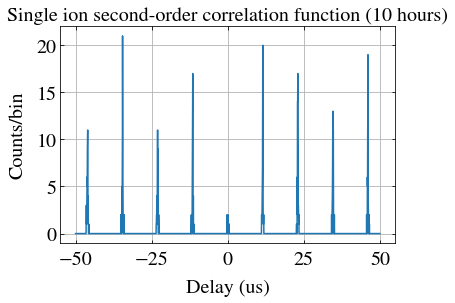

Date 2023-08-13, Time 22-51


In [11]:
index = np.load('corr.getIndex_Date 2023-08-12, Time 18-34.npy')
data_1 = np.load('corr.getData_Date 2023-08-12, Time 18-34.npy')
data_2 = np.load('corr.getData_Date 2023-08-12, Time 17-12.npy')
data_3 = np.load('corr.getData_Date 2023-08-12, Time 16-8.npy')
data_4 = np.load('corr.getData_Date 2023-08-12, Time 15-0.npy')
data_5 = np.load('corr.getData_Date 2023-08-12, Time 13-44.npy')
data_6 = np.load('corr.getData_Date 2023-08-12, Time 12-44.npy')
data_7 = np.load('corr.getData_Date 2023-08-12, Time 11-43.npy')
data_8 = np.load('corr.getData_Date 2023-08-12, Time 22-19.npy')

index = index / 1e6
# Get the correlation data
data_sum1 = data_1 + data_2 + data_3 + data_4 + data_5 + data_6 + data_7 + data_8
# Plot the g(2) function
plt.plot(index, data_sum1)
plt.title("Single ion second-order correlation function (10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('corr.getData_'+formatted_string+'_10_hours_no_merging.npy', data_sum1)
np.save('corr.getIndex_'+formatted_string+'_10_hours_no_merging.npy', index)

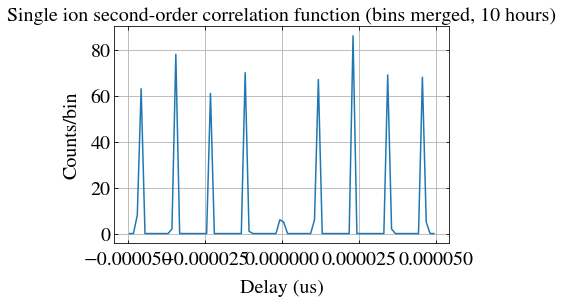

Date 2023-08-13, Time 22-41


In [7]:
sup_binsize = 25
merged_data_sum = []
for i in range(len(data_sum)//sup_binsize):
    merged_data_sum.append(np.sum(data_sum[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]) / 1e6)

# Plot the g(2) function
plt.plot(merged_index, merged_data_sum)
plt.title("Single ion second-order correlation function (bins merged, 10 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('corr.getData_'+formatted_string+'_10_hours.npy', merged_data_sum)
np.save('corr.getIndex_'+formatted_string+'_10_hours.npy', merged_index)

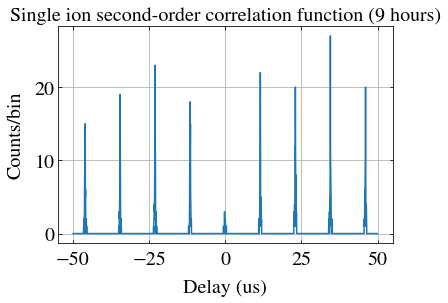

Date 2023-08-13, Time 22-51


In [12]:
index = np.load('corr.getIndex_Date 2023-08-13, Time 13-0.npy')
data_1 = np.load('corr.getData_Date 2023-08-13, Time 14-2.npy')
data_2 = np.load('corr.getData_Date 2023-08-13, Time 15-2.npy')
data_3 = np.load('corr.getData_Date 2023-08-13, Time 16-15.npy')
data_4 = np.load('corr.getData_Date 2023-08-13, Time 17-21.npy')
data_5 = np.load('corr.getData_Date 2023-08-13, Time 18-27.npy')
data_6 = np.load('corr.getData_Date 2023-08-13, Time 19-37.npy')
data_7 = np.load('corr.getData_Date 2023-08-13, Time 21-1.npy')
data_8 = np.load('corr.getData_Date 2023-08-13, Time 22-7.npy')

index = index / 1e6
# Get the correlation data
data_sum2 = data_1 + data_2 + data_3 + data_4 + data_5 + data_6 + data_7 + data_8
# Plot the g(2) function
plt.plot(index, data_sum2)
plt.title("Single ion second-order correlation function (9 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts/bin")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('corr.getData_'+formatted_string+'_9_hours_no_merging.npy', data_sum2)
np.save('corr.getIndex_'+formatted_string+'_9_hours_no_merging.npy', index)

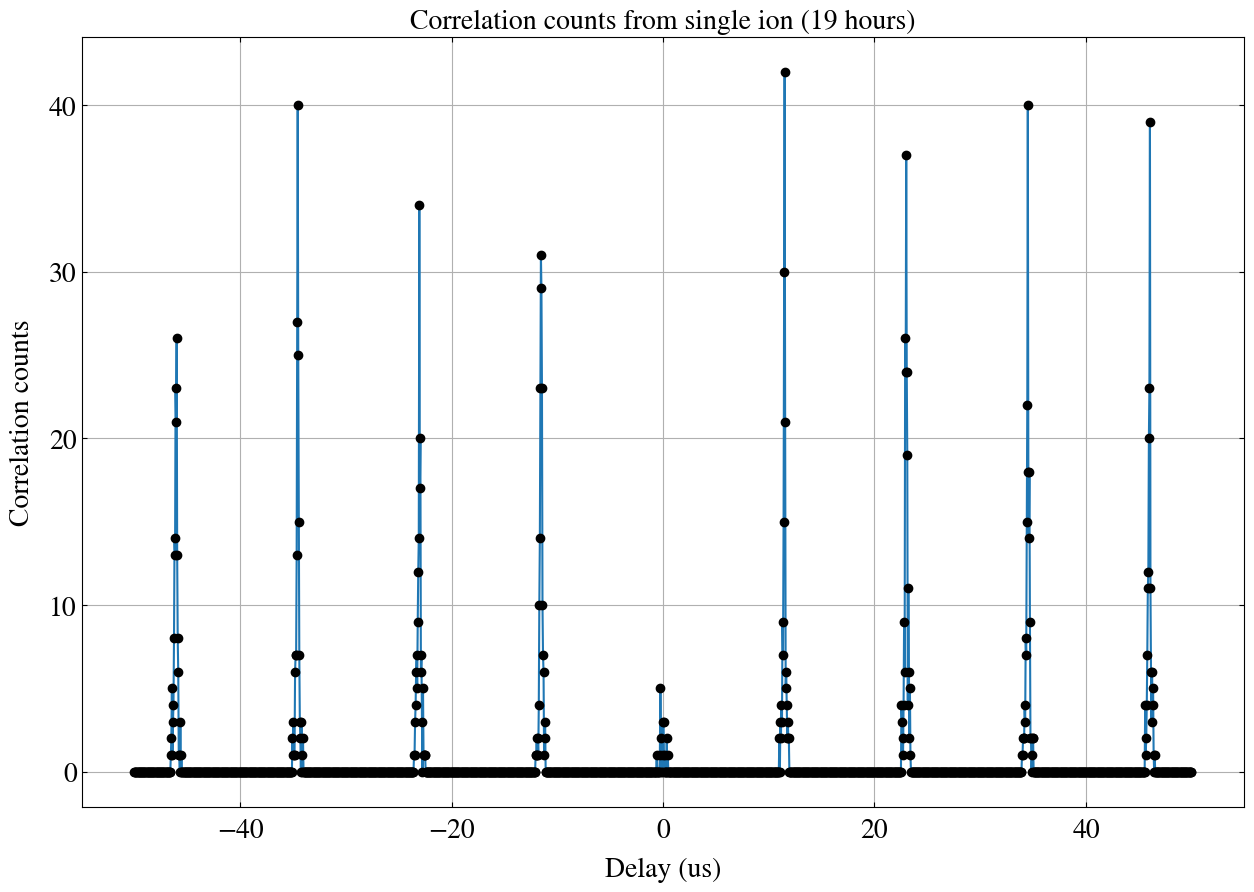

Date 2023-10-23, Time 20-45


In [3]:
index = np.load('corr.getIndex_Date 2023-08-13, Time 13-0.npy')
index = index / 1e6
# Get the correlation data
# data_sum = data_sum1 + data_sum2
data_sum = np.load('Normalized_corr.getData_Date 2023-08-28, Time 17-42_19_hours_no_merging.npy')

# k = (46000 * 3600 * 19)/(signal_counts_sum_1 * 10 * 19 * signal_counts_sum_2 * 10 * 19)

# g2_normalized = []
# # Calculate the normalized g2
# for i in range(len(data_sum)):
#     g2_normalized.append(data_sum[i] * k)

g2_normalized = data_sum #/ np.max(data_sum)

# Plot the g(2) function
plt.figure(figsize = (15, 10))
plt.plot(index, g2_normalized)
plt.plot(index, g2_normalized, 'o', color = 'black', lw = 0.5)
plt.title("Correlation counts from single ion (19 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Correlation counts")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('Correlation_counts.getData_'+formatted_string+'_19_hours_no_merging.npy', g2_normalized)
np.save('Correlation_counts.getIndex_'+formatted_string+'_19_hours_no_merging.npy', index)
# for i in range(len(g2_normalized)):
#     if (index[i] <= 1 and index[i] >= -1):
#         print(g2_normalized[i])

findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: F

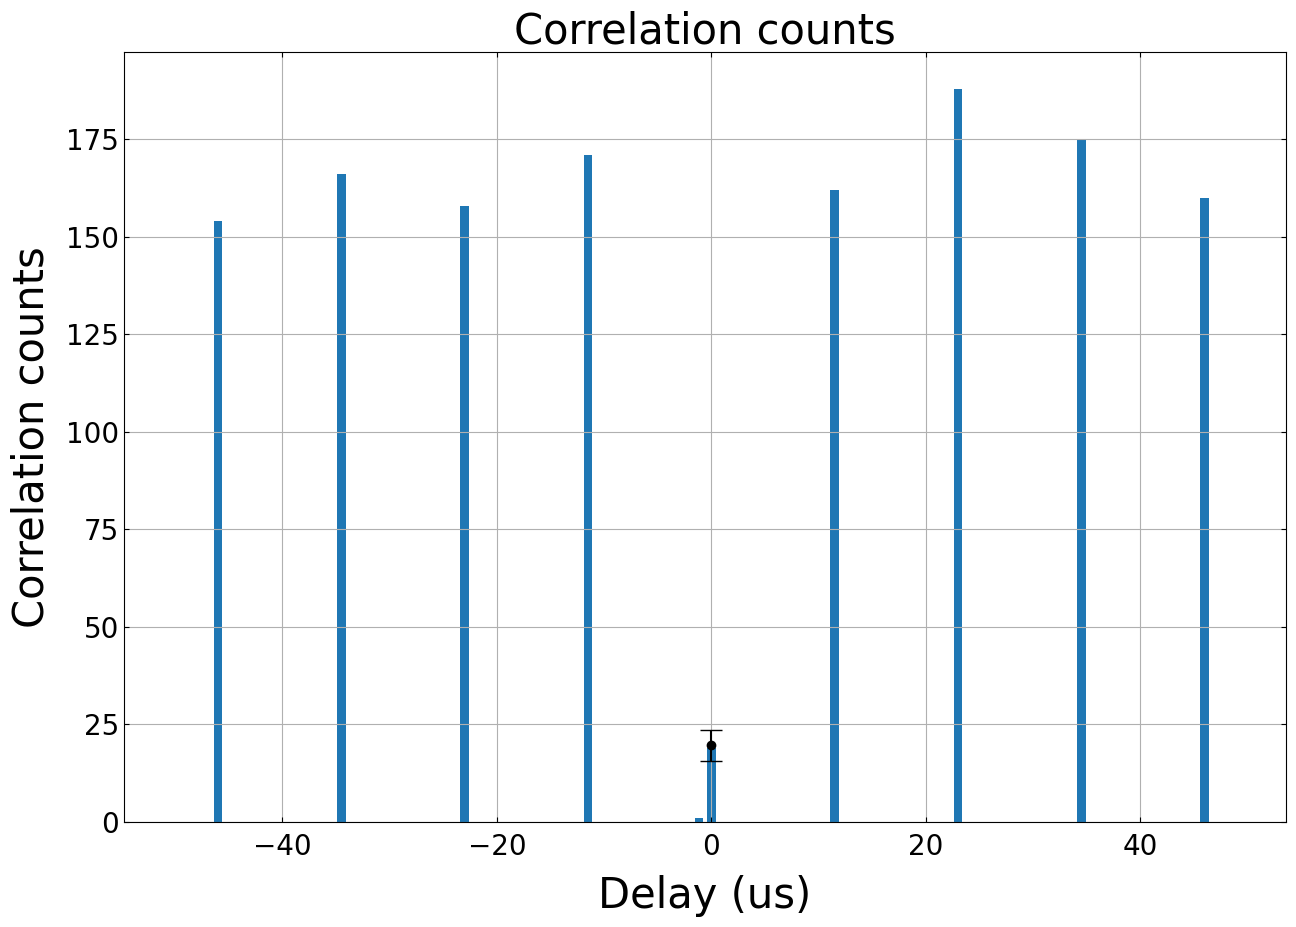

Date 2023-10-24, Time 18-45


In [13]:
sup_binsize = 23
merged_data_sum = []
for i in range(len(data_sum)//sup_binsize):
    merged_data_sum.append(np.sum(data_sum[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]))

# Set the default font to Calibri
plt.rcParams['font.family'] = 'Cambria'

# Plot the g(2) function
plt.figure(figsize = (15, 10))
x = [0]
y = [19.7]
y_upper = [1.97*2]
y_lower = [1.97*2]
errors = [y_lower, y_upper]
plt.plot(x, y, 'o', color = 'black', lw = 0.5)
plt.errorbar(x, y, yerr=errors, ecolor = 'black', capsize=8)
plt.bar(merged_index, merged_data_sum)

plt.title("Correlation counts", fontdict={'size':30})
plt.xlabel("Delay (us)", fontdict={'size':30})
plt.ylabel("Correlation counts", fontdict={'size':30})
plt.yticks(fontproperties='Cambria', size=20)
plt.xticks(fontproperties='Cambria', size=20)

plt.show()

# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
# np.save('Merged_correlation_counts.getData_'+formatted_string+'_19_hours.npy', merged_data_sum)
# np.save('Merged_correlation_counts.getIndex_'+formatted_string+'_19_hours.npy', merged_index)

In [ ]:
sup_binsize = 23
merged_data_sum = []
for i in range(len(data_sum)//sup_binsize):
    merged_data_sum.append(np.sum(data_sum[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]))

# Plot the g(2) function
plt.figure(figsize = (15, 10))
plt.plot(merged_index, merged_data_sum)
# plt.plot(index, g2_normalized, 'o', color = 'black', lw = 0.5)
plt.title("Merged correlation counts from single ion (19 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Correlation counts")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('Merged_correlation_counts.getData_'+formatted_string+'_19_hours.npy', merged_data_sum)
np.save('Merged_correlation_counts.getIndex_'+formatted_string+'_19_hours.npy', merged_index)

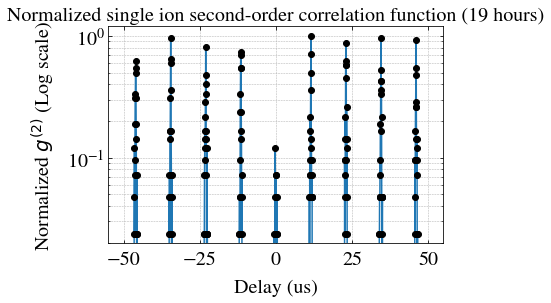

Date 2023-08-14, Time 18-26
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.023809523809523808
0.0
0.0
0.0
0.0
0.0
0.023809523809523808
0.11904761904761904
0.047619047619047616
0.0
0.0
0.023809523809523808
0.07142857142857142
0.07142857142857142
0.0
0.0
0.023809523809523808
0.0
0.0
0.047619047619047616
0.0
0.023809523809523808
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [78]:
index = np.load('corr.getIndex_Date 2023-08-13, Time 13-0.npy')
index = index / 1e6
# Get the correlation data
data_sum = data_sum1 + data_sum2

# k = (46000 * 3600 * 19)/(signal_counts_sum_1 * 10 * 19 * signal_counts_sum_2 * 10 * 19)

# g2_normalized = []
# # Calculate the normalized g2
# for i in range(len(data_sum)):
#     g2_normalized.append(data_sum[i] * k)

g2_normalized = data_sum / np.max(data_sum)

# Plot the g(2) function
plt.semilogy(index, g2_normalized)
plt.semilogy(index, g2_normalized, 'o', color = 'black', lw = 0.5)
plt.title("Normalized single ion second-order correlation function (19 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Normalized $g^{(2)}$ (Log scale)")
plt.grid(True, which="both", ls="--", linewidth=0.5) # Adding a grid
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('Normalized_log_corr.getData_'+formatted_string+'_19_hours_no_merging.npy', g2_normalized)
np.save('Normalized_log_corr.getIndex_'+formatted_string+'_19_hours_no_merging.npy', index)
for i in range(len(g2_normalized)):
    if (index[i] <= 1 and index[i] >= -1):
        print(g2_normalized[i])

In [18]:
index = np.load('corr.getIndex_Date 2023-08-13, Time 13-0.npy')
sup_binsize = 25
merged_data_sum = []
for i in range(len(data_sum)//sup_binsize):
    merged_data_sum.append(np.sum(data_sum[i*sup_binsize:i*sup_binsize+sup_binsize]))

merged_index = []
for i in range(len(index)//sup_binsize):
    merged_index.append(np.median(index[i*sup_binsize:i*sup_binsize+sup_binsize]) / 1e6)

# # Plot the g(2) function
# plt.plot(merged_index, merged_data_sum)
# plt.title("Single ion second-order correlation function (bins merged, 19 hours)", fontdict={'size':20})
# plt.xlabel("Delay (us)")
# plt.ylabel("Counts/bin")
# plt.show()
# # Getting the current date and time
# now = datetime.now()
# # Extracting the date, hour, and minute
# current_date = now.date()
# current_hour = now.hour
# current_minute = now.minute
# # Converting to a char string
# formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
# print(formatted_string)
# np.save('corr.getData_'+formatted_string+'_19_hours.npy', merged_data_sum)
# np.save('corr.getIndex_'+formatted_string+'_19_hours.npy', merged_index)

for i in range(len(merged_data_sum)):
    if (merged_data_sum[i] != 0):
        print(merged_data_sum[i])

16
138
2
164
157
1
165
6
10
10
11
151
188
173
2
143
17


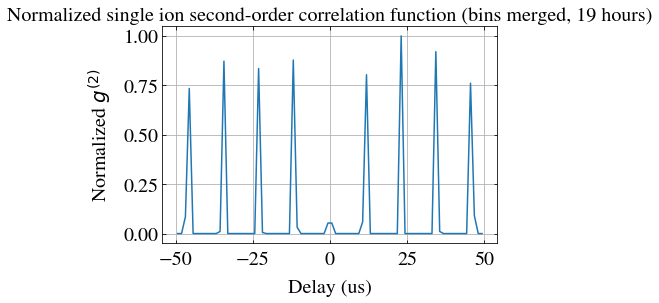

Date 2023-08-14, Time 18-25
0.0
0.0
0.0
0.05319148936170213
0.05319148936170213
0.0
0.0
0.0


In [77]:
# Assuming index is your array for time delays and data_sum is your array for second-order correlation measurement

# Calculate the average intensity
average_intensity = np.mean(merged_data_sum)

k = (46000 * 3600 * 19)/(signal_counts_sum_1 * 10 * 19 * signal_counts_sum_2 * 10 * 19)

# g2_normalized = []
# # Calculate the normalized g2
# for i in range(len(merged_data_sum)):
#     g2_normalized.append(merged_data_sum[i] * k)
# g2_normalized = merged_data_sum * 0.00632911392405
g2_normalized = merged_data_sum / np.max(merged_data_sum)

# Plot the g(2) function
plt.plot(merged_index, g2_normalized)
plt.title("Normalized single ion second-order correlation function (bins merged, 19 hours)", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Normalized $g^{(2)}$")
plt.show()
# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
print(formatted_string)
np.save('Normalized_corr.getData_'+formatted_string+'_19_hours.npy', g2_normalized)
np.save('Normalized_corr.getIndex_'+formatted_string+'_19_hours.npy', merged_index)
for i in range(len(g2_normalized)):
    if (merged_index[i] <= 5 and merged_index[i] >= -5):
        print(g2_normalized[i])

bright_window_counts = 13.866666666666667
The dummy_SNR is (2 mins): 8.296089
The fitted_SNR is (2 mins): 4.909044970125768
Total counts = 17.667361111111113 counts / s
Total signal_to_noise_ratio = 2.3299752724608482


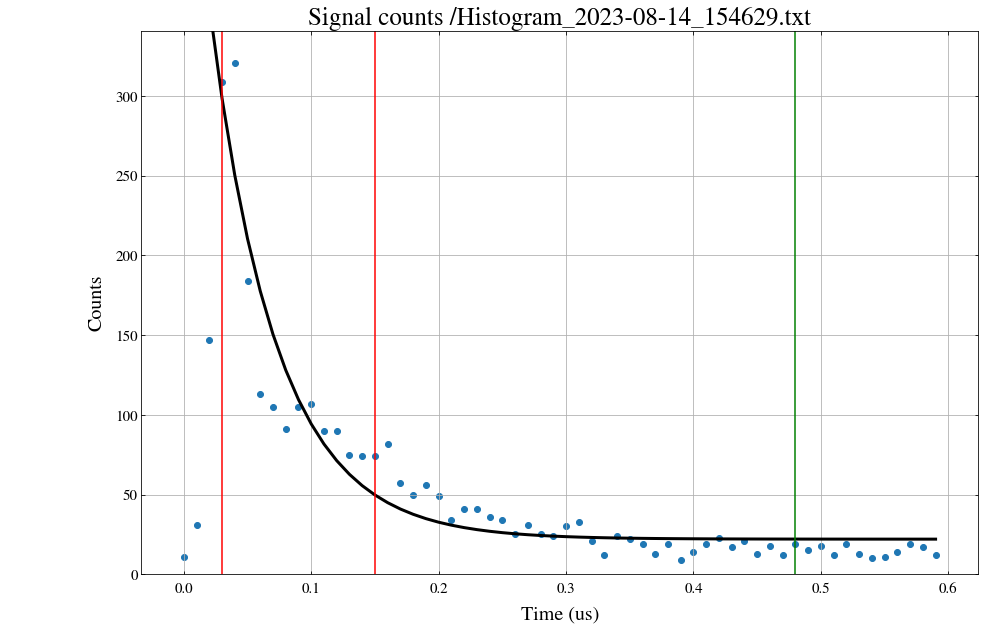

In [42]:
# Histogram_2023-08-14_154629
# Histogram_2023-08-14_155406

signal_path = "D:/Multiplexing experiment"
file_name = "/Histogram_2023-08-14_154629.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_counts_sum_2 = signal_counts_sum
signal_title = "Signal counts " + file_name

length = len(signal_raw_data)
start_point = 3
end_point = length // 4

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts =", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins):", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins):", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts =", (result1 - result2) / (120), "counts / s")   #Photon generation rate
print("Total signal_to_noise_ratio =", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig(signal_path+'/'+file_name+' data_analysis'+'.jpg')
plt.show()

In [44]:
print(signal_counts_sum_2)
print(result2)
signal_counts_sum_2 = signal_counts_sum_2 - result2

3030.0
909.9166666666666


bright_window_counts = 29.191666666666666
The dummy_SNR is (2 mins): 16.42786
The fitted_SNR is (2 mins): 10.35504249214427
Total counts = 38.79375 counts / s
Total signal_to_noise_ratio = 4.556153657939809


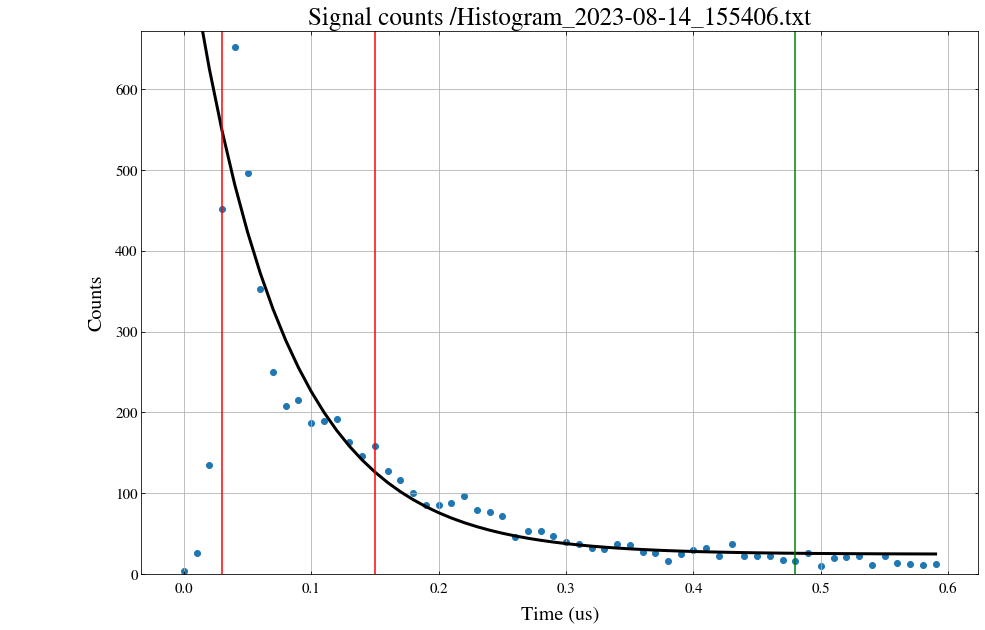

In [49]:
# Histogram_2023-08-14_154629
# Histogram_2023-08-14_155406

signal_path = "D:/Multiplexing experiment"
file_name = "/Histogram_2023-08-14_155406.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_counts_sum_1 = signal_counts_sum
signal_title = "Signal counts " + file_name

length = len(signal_raw_data)
start_point = 3
end_point = length // 4

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts =", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins):", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins):", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts =", (result1 - result2) / (120), "counts / s")   #Photon generation rate
print("Total signal_to_noise_ratio =", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig(signal_path+'/'+file_name+' data_analysis'+'.jpg')
plt.show()

In [50]:
print(signal_counts_sum_1)
print(result2)
signal_counts_sum_1 = signal_counts_sum_1 - result2

5677.0
1021.75


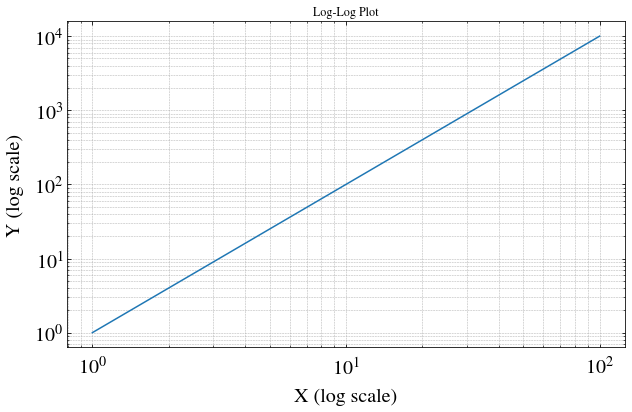

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Create some example data
x = np.logspace(0, 2, 100) # Values from 10^0 to 10^2
y = x**2

plt.figure(figsize=(10, 6))
plt.loglog(x, y) # Log-log plot
plt.title('Log-Log Plot')
plt.xlabel('X (log scale)')
plt.ylabel('Y (log scale)')
plt.grid(True, which="both", ls="--", linewidth=0.5) # Adding a grid
plt.show()